# CropCare RL — Crop Disease Management Agent
**ALU Deep Learning Summative** | Marie Elyse

**Run cells in order. Do not skip any cell.**

In [1]:
# Install dependencies 
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'gymnasium', 'stable-baselines3', 'pygame',
                'imageio', 'imageio-ffmpeg', '-q'])
print('Dependencies installed ✓')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 6.0 MB/s eta 0:00:00
Dependencies installed ✓


In [2]:
# Setup paths and copy files 
import os, sys, shutil

SRC  = '/kaggle/input/datasets/elyse003uyiringiye/final-summative/marie_elyse_rl_summative'
BASE = '/kaggle/working/elyse_rl_summative'

shutil.copytree(SRC, BASE, dirs_exist_ok=True)

os.chdir(BASE)
sys.path.insert(0, BASE)

# Create required directories
for d in ['models/dqn', 'models/pg', 'results/plots', 'results/videos']:
    os.makedirs(os.path.join(BASE, d), exist_ok=True)

print('Paths set ✓')
print('Working directory:', os.getcwd())
print('Files:', os.listdir('.'))

Paths set ✓
Working directory: /kaggle/working/elyse_rl_summative
Files: ['models', 'README.md', 'main.py', 'results', 'kaggle_notebook.ipynb', 'random_demo.py', 'environment', 'training', 'requirements.txt']


In [3]:
# Patch environment (auto-inspect on move) 
# This fixes the agent exploit where it stayed at the start cell
import os, sys, numpy as np
os.environ.setdefault('SDL_VIDEODRIVER', 'dummy')
os.environ.setdefault('SDL_AUDIODRIVER', 'dummy')

from environment.custom_env import CropDiseaseEnv

def _patched_step(self, action):
    r, c = self._agent_pos
    reward = -0.3
    terminated = False
    truncated  = False

    if action in (0, 1, 2, 3):
        dr, dc = {0:(-1,0), 1:(1,0), 2:(0,-1), 3:(0,1)}[action]
        nr, nc = r + dr, c + dc
        if 0 <= nr < self.grid_size and 0 <= nc < self.grid_size:
            self._agent_pos[:] = [nr, nc]
            if self._inspected[nr, nc] == 0:
                self._do_inspect(nr, nc)
                reward += 1.0
                d = self._true_disease[nr, nc]
                if d > 0:
                    reward += 2.0 * d
            else:
                reward -= 0.2
        else:
            reward -= 1.0

    elif action == 4:
        if self._inspected[r, c] == 0:
            self._do_inspect(r, c)
            reward += 1.0
            d = self._true_disease[r, c]
            if d > 0:
                reward += 2.0 * d
        else:
            reward -= 0.5

    elif action == 5:
        reward += self._apply_treatment(r, c, heavy=False)

    elif action == 6:
        reward += self._apply_treatment(r, c, heavy=True)

    elif action == 7:
        if self._inspected[r, c] == 0:
            reward -= 1.0
        else:
            d = self._true_disease[r, c]
            if d == 0 or self._treated[r, c] == 1:
                reward += 5.0
            else:
                reward -= 8.0 * d
                self._episode_missed += 1
            self._inspected[r, c] = 2

    self._spread_disease()
    self._steps += 1
    self._total_reward += reward

    all_decided = bool(np.all(self._inspected > 0))
    if all_decided:
        terminated = True
        efficiency = self._doses / self.max_treatment_doses
        reward += 30.0 + 20.0 * efficiency

    if self._steps >= self.max_steps:
        truncated = True
        undecided_sick = int(np.sum(
            (self._true_disease > 0) & (self._inspected == 0)
        ))
        reward -= 2.0 * undecided_sick

    if self.render_mode == 'human':
        self.render()

    return self._get_obs(), reward, terminated, truncated, self._get_info()

CropDiseaseEnv.step = _patched_step

# Quick sanity check
env = CropDiseaseEnv()
obs, info = env.reset(seed=0)
for _ in range(64):
    obs, r, term, trunc, info = env.step(int(env.np_random.integers(0, 4)))
    if term or trunc: break
print(f'Patch verified — inspected after 64 random moves: {info["cells_inspected"]}/64')
env.close()

Patch verified — inspected after 64 random moves: 25/64


In [4]:
# Random agent demo 
import imageio, numpy as np
from environment.custom_env import CropDiseaseEnv, ACTION_LABELS

env = CropDiseaseEnv(grid_size=8, max_steps=200,
                     render_mode='rgb_array', spread_probability=0.0)
obs, info = env.reset(seed=42)
frames = []
total_reward = 0.0

print(f'Random Agent Demo — diseased cells: {info["total_diseased"]}/64')

for step in range(200):
    roll = env.np_random.random()
    if roll < 0.60:
        action = int(env.np_random.integers(0, 4))
    elif roll < 0.85:
        action = 4
    else:
        action = int(env.np_random.integers(5, 8))

    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    env._visible_disease = env._true_disease.copy()
    frame = env.render()
    if frame is not None:
        frames.append(frame)
    if terminated or truncated:
        break

print(f'Steps: {step+1} | Reward: {total_reward:.1f} | Inspected: {info["cells_inspected"]}/64')
env.close()

path = 'results/videos/random_agent_demo.mp4'
writer = imageio.get_writer(path, fps=8, codec='libx264',
                             quality=7, macro_block_size=None)
for f in frames:
    writer.append_data(f)
writer.close()
print(f'Saved → {path}')

Random Agent Demo — diseased cells: 18/64
Steps: 200 | Reward: -35.1 | Inspected: 29/64
Saved → results/videos/random_agent_demo.mp4


In [5]:
# Train DQN — all 10 configs 
from training.dqn_training import train_dqn, save_csv, plot_results

dqn_results = []
for i in range(10):
    r = train_dqn(i, timesteps=300_000, verbose=0)
    dqn_results.append(r)
    print(f'DQN run {i} done — mean_reward={r["mean_ep_reward"]}')

save_csv(dqn_results)
plot_results(dqn_results)
print('DQN complete ✓')

2026-03-25 08:34:45.403577: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774427685.618693      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774427685.682758      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774427686.197522      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774427686.197571      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774427686.197574      55 computation_placer.cc:177] computation placer alr


  DQN Run  0 / 9
  Config: lr=0.001, gamma=0.99, batch=64, buf=50000
  Net:    [128, 128]    expl=0.15
  ✓  Run 0 done in 566.6s | mean_ep_reward=751.8 ± 466.5
DQN run 0 done — mean_reward=751.82

  DQN Run  1 / 9
  Config: lr=0.0005, gamma=0.99, batch=64, buf=100000
  Net:    [128, 128]    expl=0.2
  ✓  Run 1 done in 565.1s | mean_ep_reward=-425.7 ± 519.7
DQN run 1 done — mean_reward=-425.71

  DQN Run  2 / 9
  Config: lr=0.002, gamma=0.95, batch=32, buf=10000
  Net:    [64, 64]    expl=0.1
  ✓  Run 2 done in 554.4s | mean_ep_reward=235.3 ± 474.6
DQN run 2 done — mean_reward=235.28

  DQN Run  3 / 9
  Config: lr=0.001, gamma=0.99, batch=128, buf=50000
  Net:    [256, 256]    expl=0.2
  ✓  Run 3 done in 567.8s | mean_ep_reward=776.1 ± 389.4
DQN run 3 done — mean_reward=776.1

  DQN Run  4 / 9
  Config: lr=0.0005, gamma=0.99, batch=64, buf=50000
  Net:    [128, 128]    expl=0.3
  ✓  Run 4 done in 562.6s | mean_ep_reward=997.5 ± 116.2
DQN run 4 done — mean_reward=997.52

  DQN Run  5 / 

In [6]:
# Train PPO — all 10 configs 
from training.pg_training import train_sb3, save_csv, plot_results

ppo_results = []
for i in range(10):
    r = train_sb3('ppo', i, timesteps=300_000, verbose=0)
    ppo_results.append(r)
    print(f'PPO run {i} done — mean_reward={r["mean_ep_reward"]}')

save_csv(ppo_results, 'ppo')
plot_results(ppo_results, 'ppo')
print('PPO complete ✓')


  PPO Run  0 / 9
  lr=0.0003, gamma=0.99, n_steps=2048
  ent_coef=0.01, vf_coef=0.5, net=[128, 128]


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


  ✓  PPO Run 0 done in 886.6s | mean_ep_reward=293.7 ± 34.6
PPO run 0 done — mean_reward=293.72

  PPO Run  1 / 9
  lr=0.001, gamma=0.99, n_steps=512
  ent_coef=0.01, vf_coef=0.5, net=[128, 128]
  ✓  PPO Run 1 done in 878.2s | mean_ep_reward=890.9 ± 232.8
PPO run 1 done — mean_reward=890.86

  PPO Run  2 / 9
  lr=0.0003, gamma=0.95, n_steps=1024
  ent_coef=0.01, vf_coef=0.5, net=[128, 128]
  ✓  PPO Run 2 done in 865.7s | mean_ep_reward=213.8 ± 113.7
PPO run 2 done — mean_reward=213.82

  PPO Run  3 / 9
  lr=0.0003, gamma=0.99, n_steps=2048
  ent_coef=0.01, vf_coef=0.5, net=[128, 128]
  ✓  PPO Run 3 done in 867.8s | mean_ep_reward=257.7 ± 60.6
PPO run 3 done — mean_reward=257.74

  PPO Run  4 / 9
  lr=0.0003, gamma=0.99, n_steps=2048
  ent_coef=0.01, vf_coef=0.5, net=[128, 128]
  ✓  PPO Run 4 done in 869.4s | mean_ep_reward=296.3 ± 36.9
PPO run 4 done — mean_reward=296.26

  PPO Run  5 / 9
  lr=0.0003, gamma=0.99, n_steps=1024
  ent_coef=0.05, vf_coef=0.5, net=[128, 128]
  ✓  PPO Run 5 

In [7]:
# Train REINFORCE — all 10 configs 
from training.reinforce import train_reinforce, save_csv as reinforce_csv, plot_results as reinforce_plots

reinforce_results = []
for i in range(10):
    r = train_reinforce(i, n_episodes=2000, verbose=False)
    reinforce_results.append(r)
    print(f'REINFORCE run {i} done — mean_reward={r["mean_ep_reward"]}')

reinforce_csv(reinforce_results)
reinforce_plots(reinforce_results)
print('REINFORCE complete ✓')

REINFORCE run 0 done — mean_reward=172.36
REINFORCE run 1 done — mean_reward=147.57
REINFORCE run 2 done — mean_reward=191.64
REINFORCE run 3 done — mean_reward=173.89
REINFORCE run 4 done — mean_reward=208.8
REINFORCE run 5 done — mean_reward=156.77
REINFORCE run 6 done — mean_reward=197.33
REINFORCE run 7 done — mean_reward=210.65
REINFORCE run 8 done — mean_reward=131.74
REINFORCE run 9 done — mean_reward=156.54
  Results CSV → results/reinforce_results.csv
  Reward curves → results/plots/reinforce_reward_curves.png
  Entropy curves → results/plots/reinforce_entropy.png
REINFORCE complete ✓


In [8]:
#  View results tables 
import pandas as pd, os

for algo in ['dqn', 'ppo', 'reinforce']:
    path = f'results/{algo}_results.csv'
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f'\n=== {algo.upper()} Results ===')
        display(df.sort_values('mean_ep_reward', ascending=False))
        best = df.loc[df.mean_ep_reward.idxmax()]
        print(f'  Best → run {int(best["run"])} | mean_reward={best["mean_ep_reward"]:.2f}')


=== DQN Results ===


,run,learning_rate,gamma,batch_size,buffer_size,exploration_fraction,exploration_final_eps,target_update_interval,net_arch,mean_ep_reward,std_ep_reward,max_ep_reward,n_episodes,train_time_s
4,4,0.0005,0.99,64,50000,0.30,0.02,500,"[128, 128]",997.52,116.24,1074.0,1200,562.6
3,3,0.0010,0.99,128,50000,0.20,0.05,1000,"[256, 256]",776.10,389.39,1089.3,1200,567.8
0,0,0.0010,0.99,64,50000,0.15,0.05,500,"[128, 128]",751.82,466.50,1068.3,1200,566.6
8,8,0.0010,0.98,64,50000,0.15,0.05,200,"[128, 128]",621.07,417.38,1057.8,1200,752.8
5,5,0.0010,0.90,64,50000,0.15,0.05,500,"[128, 64]",616.77,739.12,1106.6,1200,570.4
6,6,0.0003,0.99,256,100000,0.20,0.02,1000,"[256, 128]",567.22,613.34,1082.0,1200,787.4
7,7,0.0001,0.99,64,50000,0.25,0.05,500,"[128, 128]",545.25,677.29,1077.0,1200,559.3
2,2,0.0020,0.95,32,10000,0.10,0.10,300,"[64, 64]",235.28,474.64,1028.8,1200,554.4
9,9,0.0005,0.99,128,75000,0.20,0.03,750,[512],232.19,436.48,1076.5,1200,519.7
1,1,0.0005,0.99,64,100000,0.20,0.05,500,"[128, 128]",-425.71,519.75,1063.8,1200,565.1


  Best → run 4 | mean_reward=997.52

=== PPO Results ===


,run,learning_rate,gamma,n_steps,ent_coef,vf_coef,net_arch,mean_ep_reward,std_ep_reward,max_ep_reward,n_episodes,train_time_s,batch_size,n_epochs,clip_range
1,1,0.0010,0.99,512,0.01,0.5,"[128, 128]",890.86,232.78,1068.00,1200,878.2,64,10,0.2
4,4,0.0003,0.99,2048,0.01,0.5,"[128, 128]",296.26,36.90,375.60,1204,869.4,64,10,0.3
0,0,0.0003,0.99,2048,0.01,0.5,"[128, 128]",293.72,34.58,381.43,1204,886.6,64,10,0.2
8,8,0.0003,0.99,1024,0.01,1.0,"[128, 128]",291.35,58.48,437.10,1201,874.1,64,10,0.2
7,7,0.0003,0.99,2048,0.01,0.5,"[256, 256, 128]",289.10,37.61,379.40,1204,762.6,128,5,0.2
6,6,0.0003,0.99,1024,0.00,0.5,"[128, 128]",264.98,84.74,414.87,1201,864.6,64,10,0.2
3,3,0.0003,0.99,2048,0.01,0.5,"[128, 128]",257.74,60.59,360.00,1204,867.8,64,10,0.1
9,9,0.0001,0.99,2048,0.01,0.5,"[128, 128]",247.58,60.68,406.77,1205,1072.8,64,20,0.2
5,5,0.0003,0.99,1024,0.05,0.5,"[128, 128]",228.57,33.82,342.00,1200,863.4,64,10,0.2
2,2,0.0003,0.95,1024,0.01,0.5,"[128, 128]",213.82,113.70,412.83,1201,865.7,64,10,0.2


  Best → run 1 | mean_reward=890.86

=== REINFORCE Results ===


,run,learning_rate,gamma,hidden_sizes,normalize_returns,entropy_coef,grad_clip,mean_ep_reward,std_ep_reward,max_ep_reward,n_episodes,train_time_s
7,7,0.0010,0.90,"[128, 128]",True,0.01,1.0,210.65,36.98,376.5,2000,1066.1
4,4,0.0010,0.95,"[128, 128]",True,0.00,1.0,208.80,50.69,362.8,2000,1069.8
6,6,0.0010,0.99,[512],True,0.01,1.0,197.33,53.37,365.9,2000,977.2
2,2,0.0010,0.99,"[128, 128]",False,0.01,1.0,191.64,61.94,355.4,2000,1072.7
3,3,0.0010,0.99,"[128, 128]",True,0.05,1.0,173.89,70.30,377.2,2000,1074.0
0,0,0.0010,0.99,"[128, 128]",True,0.01,1.0,172.36,52.88,331.6,2000,1090.5
5,5,0.0005,0.99,"[256, 256, 128]",True,0.01,0.5,156.77,56.34,322.3,2000,1198.6
9,9,0.0010,0.99,"[128, 64]",True,0.02,NaN,156.54,52.84,346.2,2000,1074.0
1,1,0.0005,0.99,"[128, 128]",True,0.01,1.0,147.57,51.22,311.3,2000,1076.8
8,8,0.0001,0.99,"[128, 128]",True,0.01,1.0,131.74,56.00,273.2,2000,1092.2


  Best → run 7 | mean_reward=210.65


Found 8 plots

results/plots/dqn_loss_curves.png


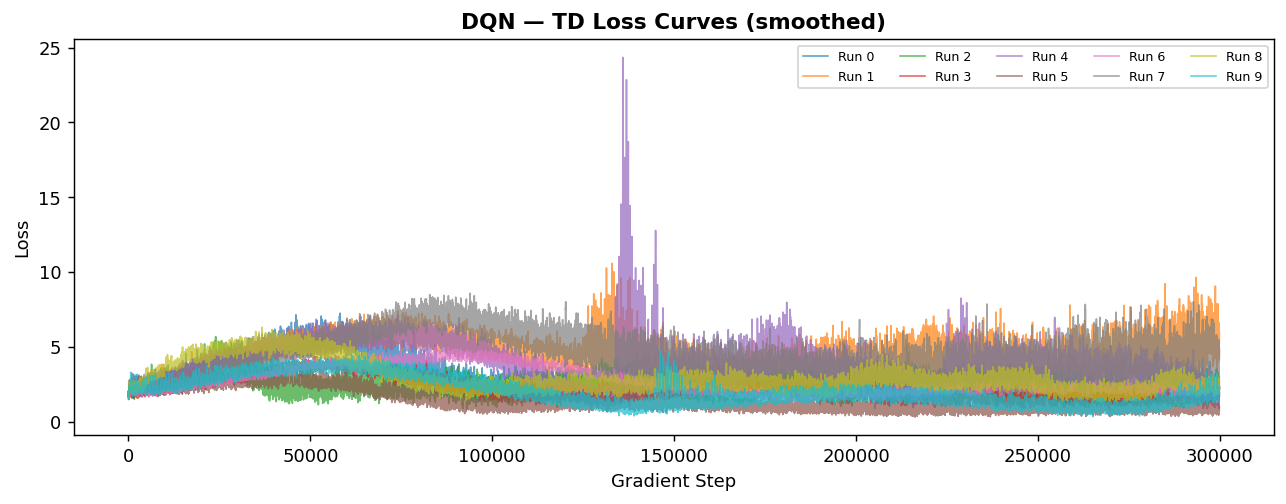


results/plots/dqn_reward_curves.png


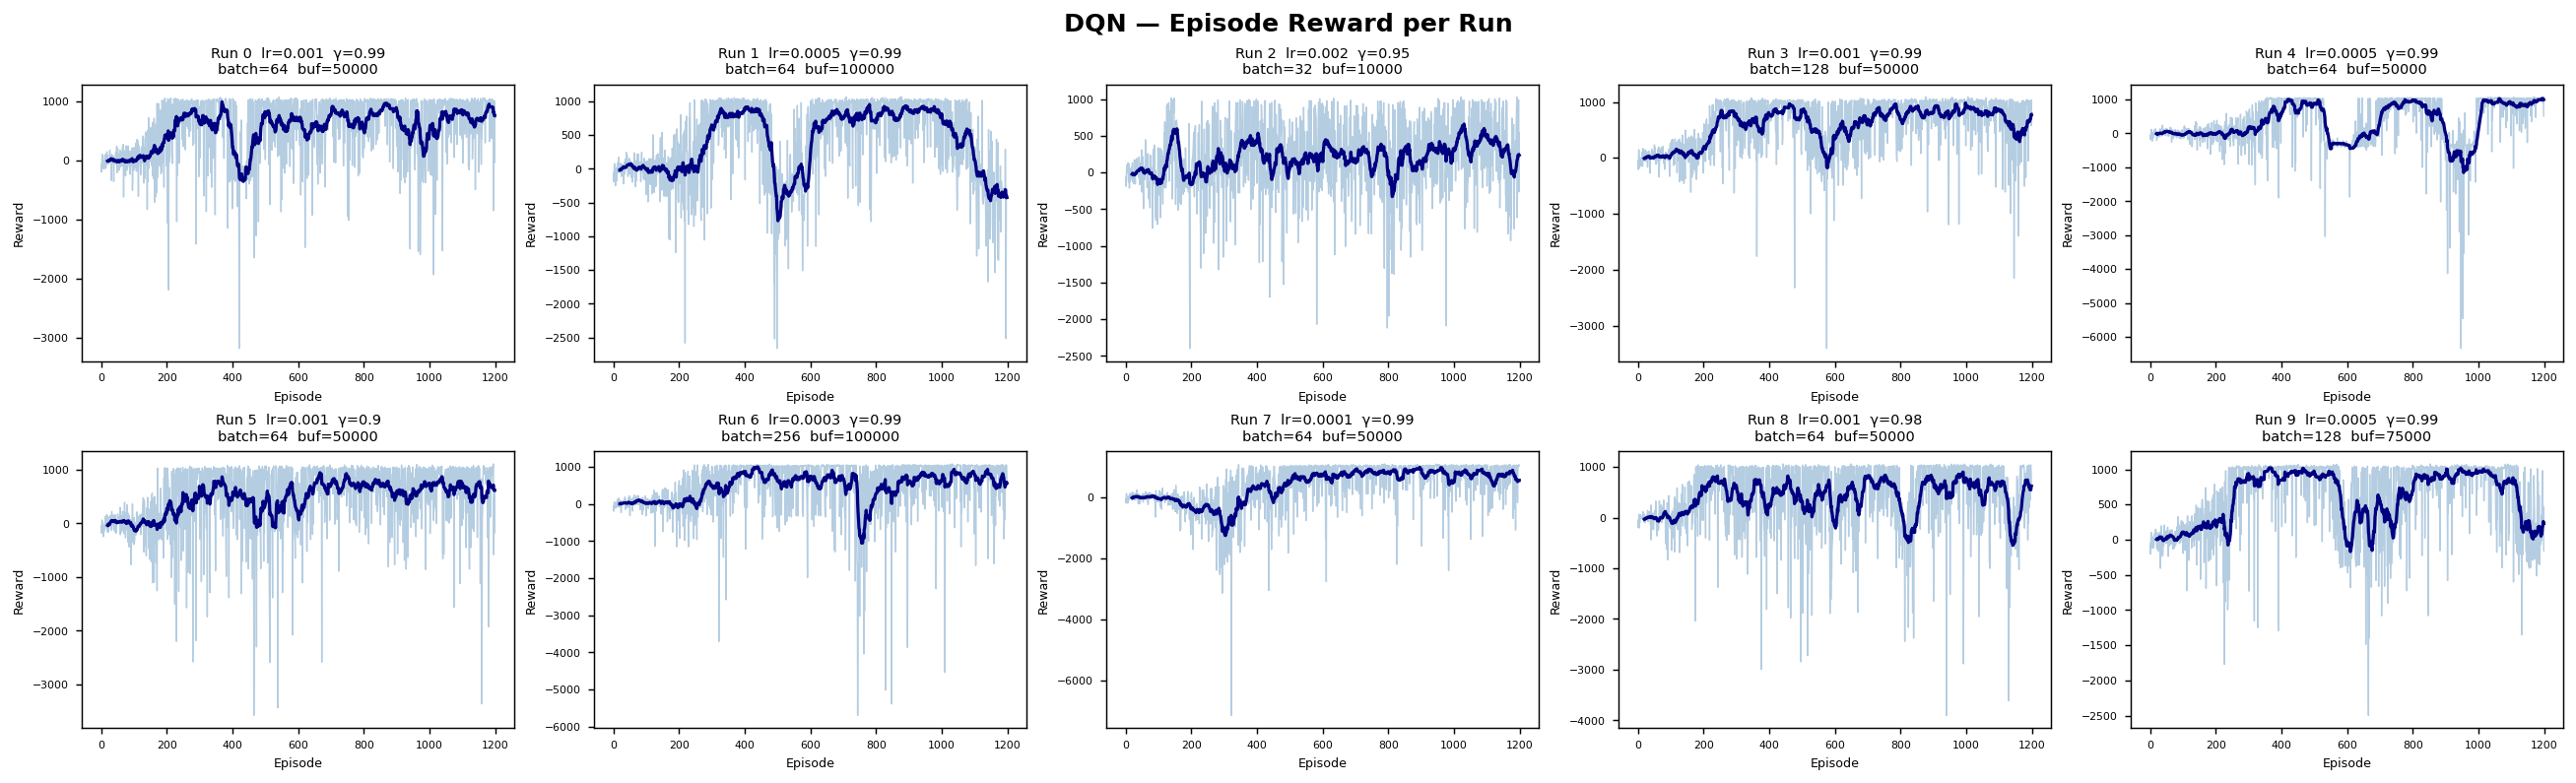


results/plots/dqn_summary.png


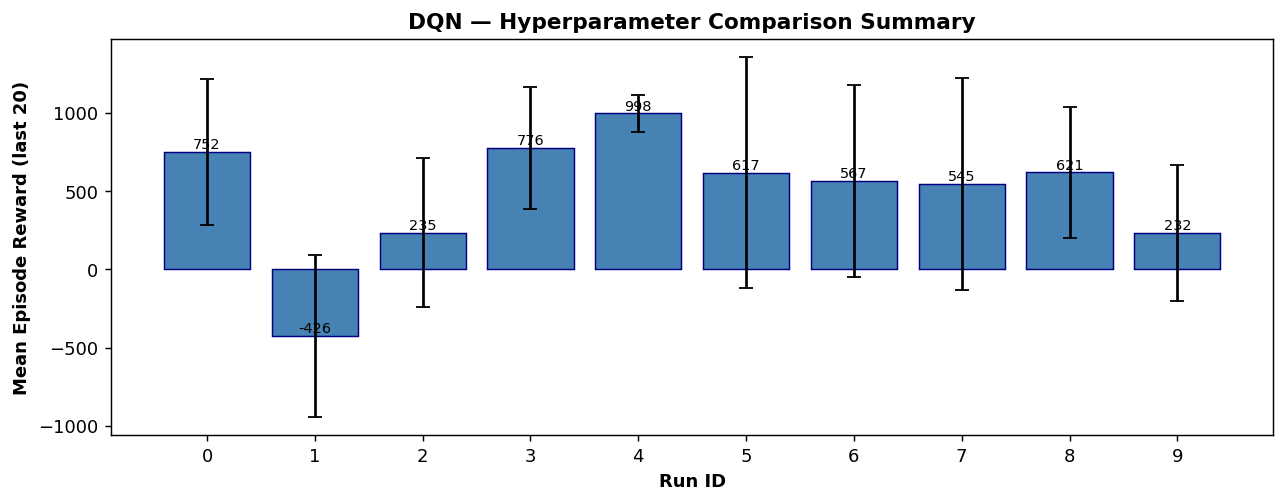


results/plots/ppo_entropy.png


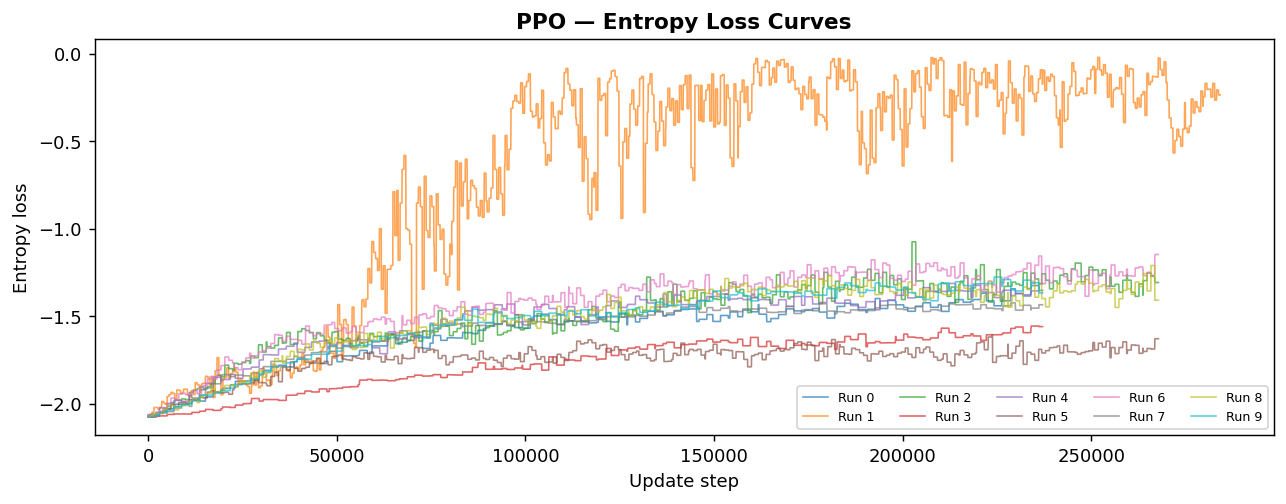


results/plots/ppo_reward_curves.png


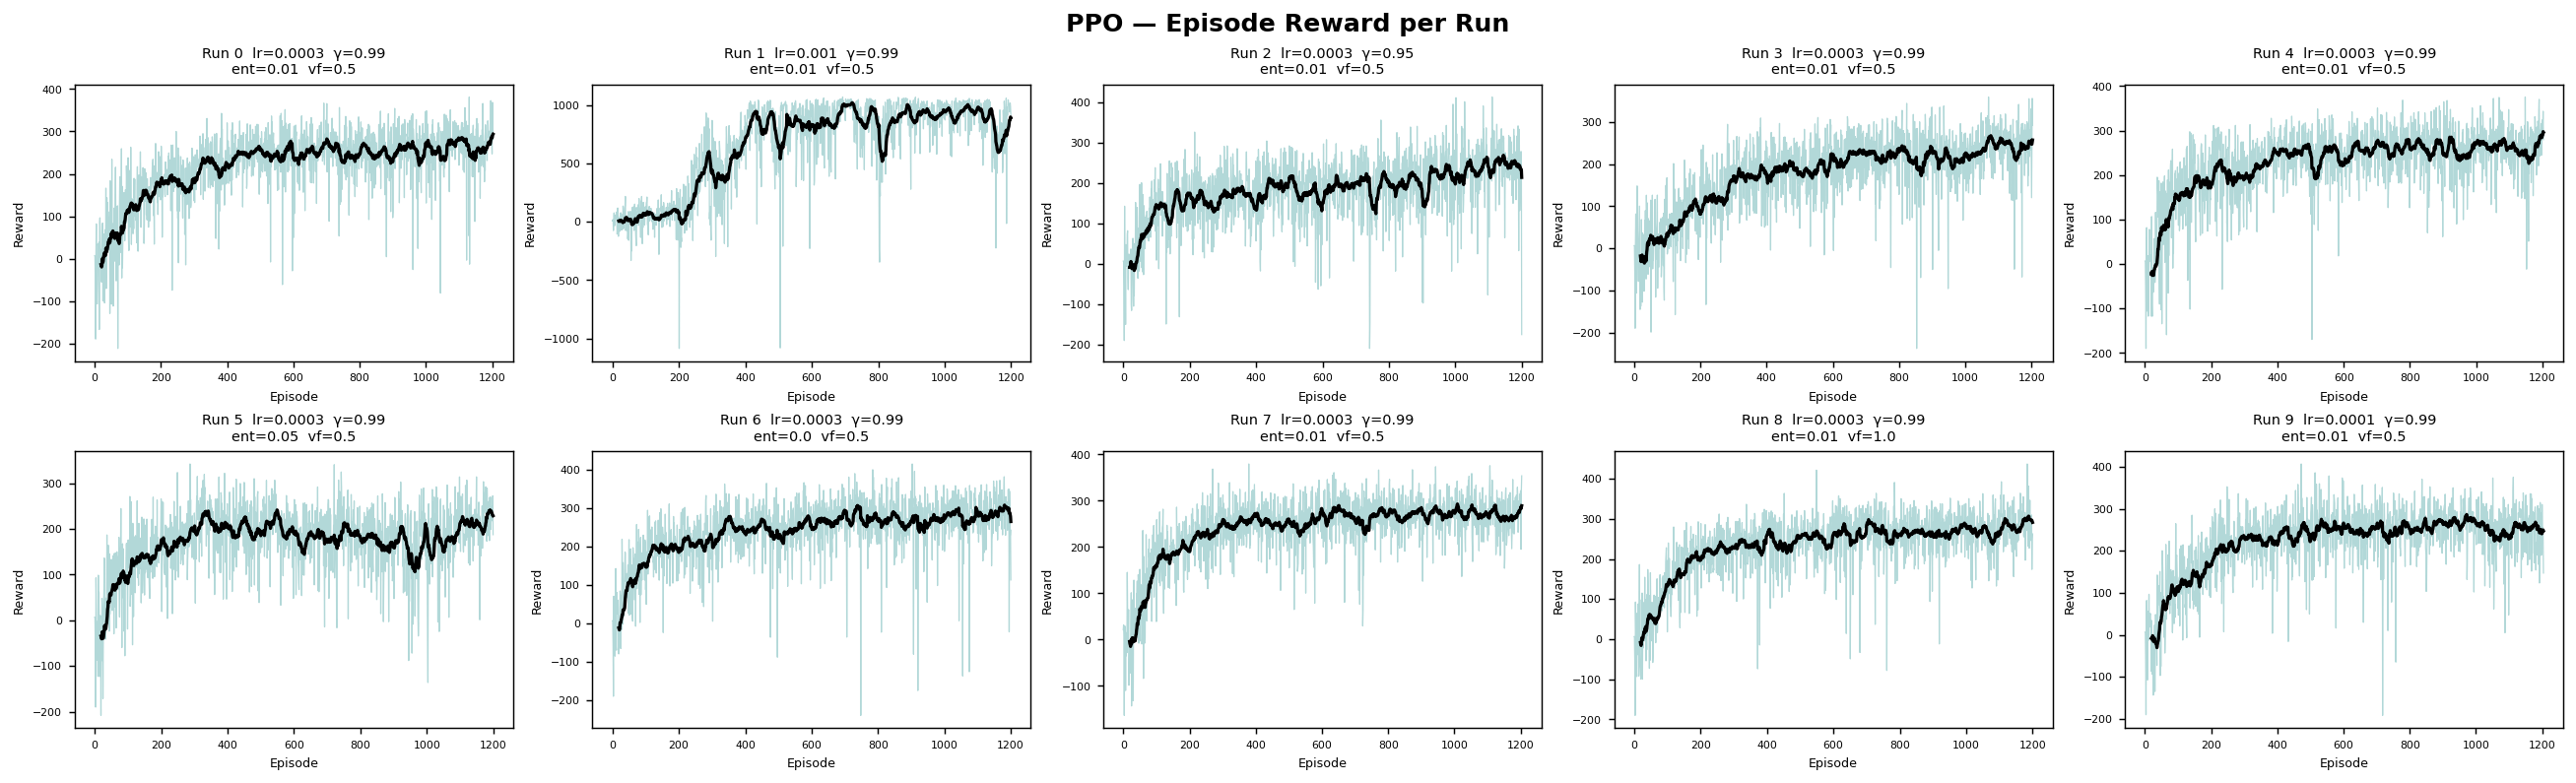


results/plots/ppo_summary.png


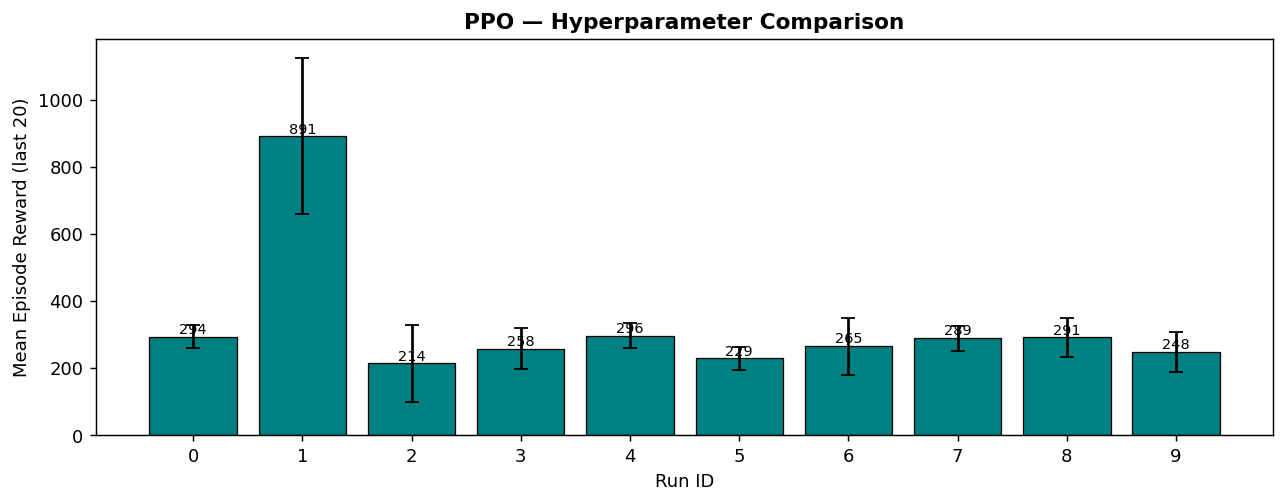


results/plots/reinforce_entropy.png


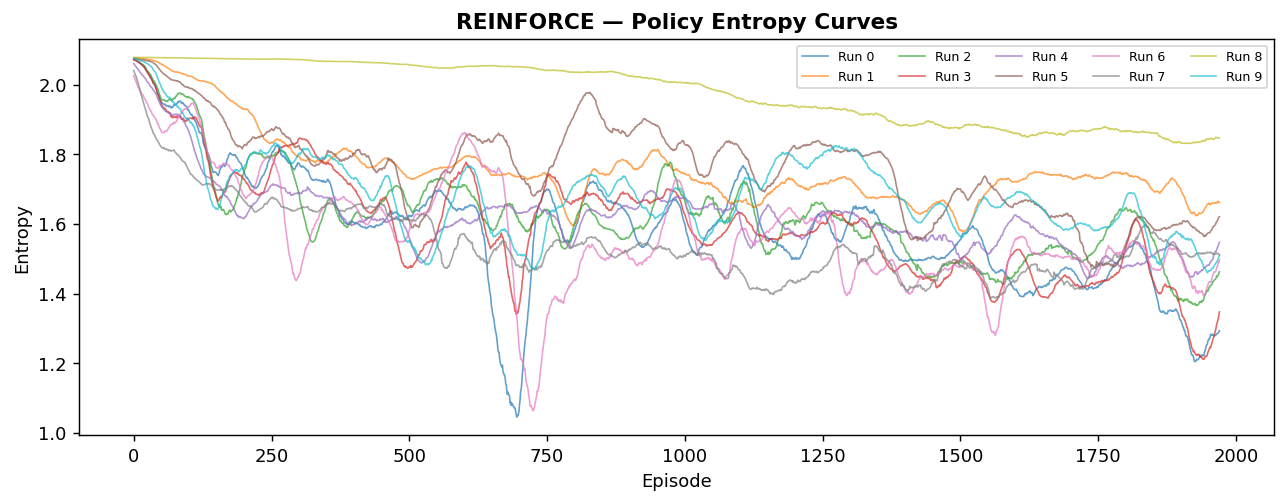


results/plots/reinforce_reward_curves.png


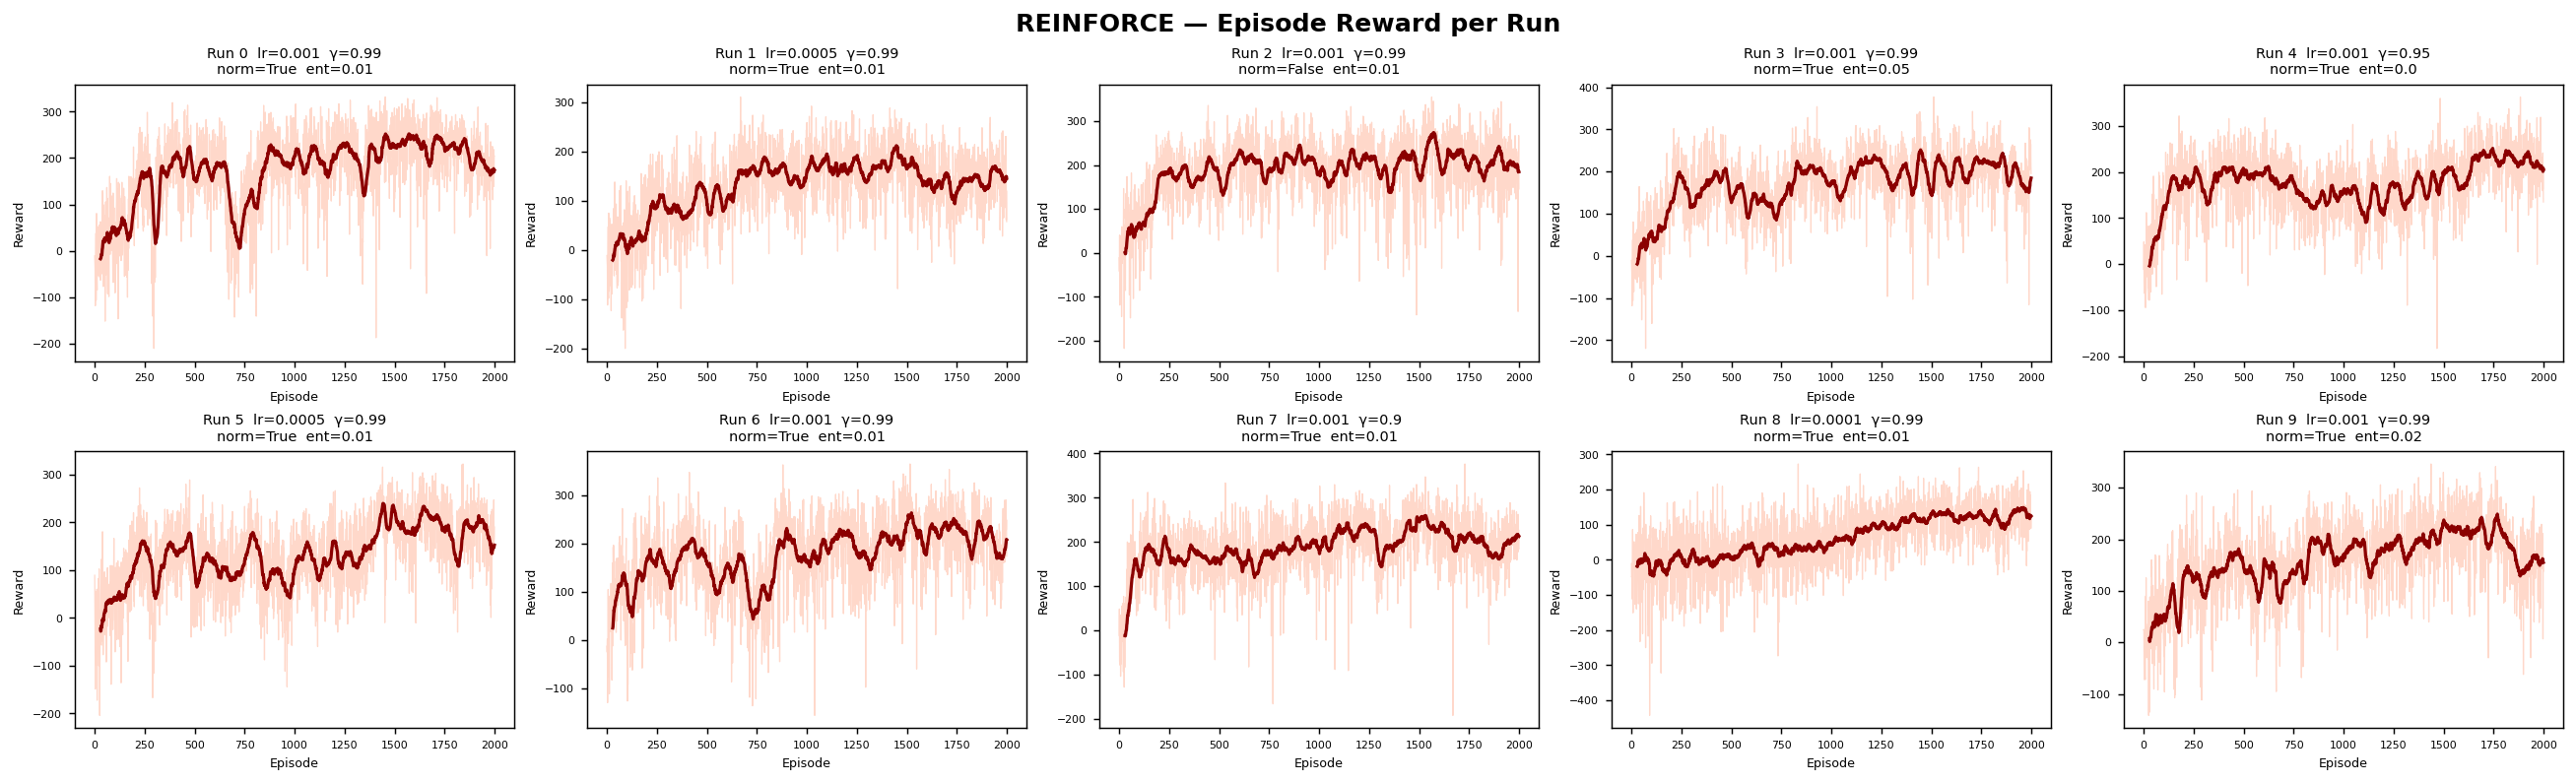

In [9]:
#  Display all training plots 
import glob
from IPython.display import Image, display

plot_files = sorted(glob.glob('results/plots/*.png'))
print(f'Found {len(plot_files)} plots')
for p in plot_files:
    print(f'\n{p}')
    display(Image(p))

In [10]:
#  Evaluate all models and find real best
import numpy as np
from stable_baselines3 import DQN, PPO
from environment.custom_env import CropDiseaseEnv

def evaluate(model, n=3):
    rewards, inspected = [], []
    for ep in range(n):
        env = CropDiseaseEnv(grid_size=8, max_steps=250, spread_probability=0.0)
        obs, _ = env.reset(seed=ep * 7)
        total_r = 0.0
        while True:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, info = env.step(int(action))
            total_r += r
            if term or trunc:
                inspected.append(info['cells_inspected'])
                break
        rewards.append(total_r)
        env.close()
    return np.mean(rewards), np.mean(inspected)

best_model_obj = None
best_algo      = None
best_inspected = 0
best_reward    = -1e9

for i in range(10):
    path = f'models/dqn/dqn_run_{i}.zip'
    if os.path.exists(path):
        m = DQN.load(path)
        r, ins = evaluate(m)
        print(f'DQN run {i:>2} | reward={r:>+8.1f} | inspected={ins:.1f}/64')
        if ins > best_inspected or (ins == best_inspected and r > best_reward):
            best_inspected = ins; best_reward = r
            best_model_obj = m;   best_algo = f'dqn_run_{i}'

for i in range(10):
    path = f'models/pg/ppo_run_{i}.zip'
    if os.path.exists(path):
        m = PPO.load(path)
        r, ins = evaluate(m)
        print(f'PPO run {i:>2} | reward={r:>+8.1f} | inspected={ins:.1f}/64')
        if ins > best_inspected or (ins == best_inspected and r > best_reward):
            best_inspected = ins; best_reward = r
            best_model_obj = m;   best_algo = f'ppo_run_{i}'

print(f'\n✓ Best model: {best_algo} | reward={best_reward:.1f} | inspected={best_inspected:.1f}/64')

DQN run  0 | reward= +1133.0 | inspected=1.0/64
DQN run  1 | reward=  -331.7 | inspected=8.0/64
DQN run  2 | reward= +1136.0 | inspected=3.7/64
DQN run  3 | reward= +1129.0 | inspected=2.0/64
DQN run  4 | reward= +1125.0 | inspected=1.0/64
DQN run  5 | reward= +1133.0 | inspected=1.0/64
DQN run  6 | reward= +1126.7 | inspected=2.0/64
DQN run  7 | reward= +1133.0 | inspected=1.0/64
DQN run  8 | reward= +1125.0 | inspected=1.0/64
DQN run  9 | reward=  -250.6 | inspected=13.0/64


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


PPO run  0 | reward=  -192.3 | inspected=38.7/64
PPO run  1 | reward= +1105.0 | inspected=11.7/64
PPO run  2 | reward=  -168.1 | inspected=33.0/64
PPO run  3 | reward=  -272.2 | inspected=23.0/64
PPO run  4 | reward=  -132.4 | inspected=37.7/64
PPO run  5 | reward=  -315.7 | inspected=10.3/64
PPO run  6 | reward=  -167.1 | inspected=35.3/64
PPO run  7 | reward=  -243.8 | inspected=28.7/64
PPO run  8 | reward=  -229.9 | inspected=28.7/64
PPO run  9 | reward=   -93.9 | inspected=36.0/64

✓ Best model: ppo_run_0 | reward=-192.3 | inspected=38.7/64


In [11]:
# Record best agent video 
import imageio
from environment.custom_env import CropDiseaseEnv

for ep in range(3):
    env = CropDiseaseEnv(grid_size=8, max_steps=250,
                         render_mode='rgb_array', spread_probability=0.0)
    obs, info = env.reset(seed=ep * 10)
    frames = []
    total_reward = 0.0

    while True:
        action, _ = best_model_obj.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(int(action))
        total_reward += reward
        env._visible_disease = env._true_disease.copy()
        frame = env.render()
        if frame is not None:
            frames.append(frame)
        if terminated or truncated:
            print(f'Ep {ep+1} | reward={total_reward:.1f} | '
                  f'inspected={info["cells_inspected"]}/64 | '
                  f'treated={info["cells_treated"]}')
            break
    env.close()

    path = f'results/videos/{best_algo}_ep{ep+1}.mp4'
    writer = imageio.get_writer(path, fps=10, codec='libx264',
                                 quality=7, macro_block_size=None)
    for f in frames:
        writer.append_data(f)
    writer.close()
    print(f'Saved → {path}')

Ep 1 | reward=-209.0 | inspected=33/64 | treated=2
Saved → results/videos/ppo_run_0_ep1.mp4
Ep 2 | reward=-263.0 | inspected=28/64 | treated=1
Saved → results/videos/ppo_run_0_ep2.mp4
Ep 3 | reward=-255.0 | inspected=27/64 | treated=2
Saved → results/videos/ppo_run_0_ep3.mp4


Saved: results/plots/all_algorithms_comparison.png


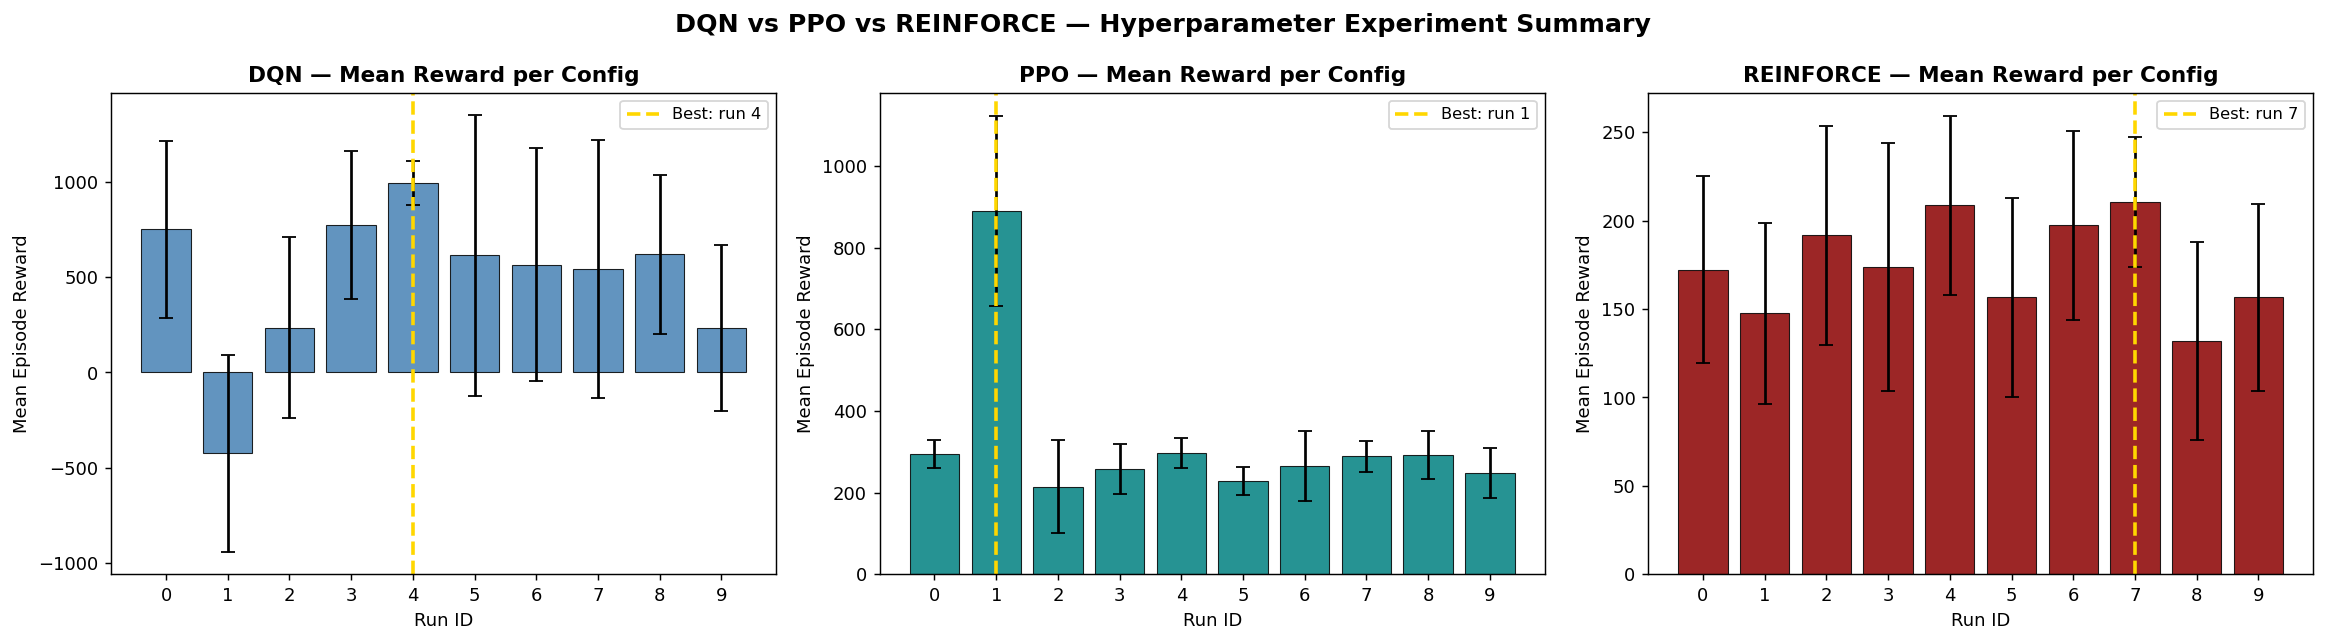

In [12]:
#  All algorithms comparison plot
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import pandas as pd, numpy as np, os

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('DQN vs PPO vs REINFORCE — Hyperparameter Experiment Summary',
             fontsize=14, fontweight='bold')

algo_colors = {'dqn': 'steelblue', 'ppo': 'teal', 'reinforce': 'darkred'}

for i, algo in enumerate(['dqn', 'ppo', 'reinforce']):
    path = f'results/{algo}_results.csv'
    if not os.path.exists(path):
        continue
    df  = pd.read_csv(path).sort_values('run')
    ax  = axes[i]
    col = algo_colors[algo]
    ax.bar(df['run'], df['mean_ep_reward'],
           yerr=df['std_ep_reward'], capsize=4,
           color=col, edgecolor='black', linewidth=0.6, alpha=0.85)
    ax.set_title(f'{algo.upper()} — Mean Reward per Config', fontweight='bold')
    ax.set_xlabel('Run ID')
    ax.set_ylabel('Mean Episode Reward')
    ax.set_xticks(df['run'])
    best_run = df.loc[df.mean_ep_reward.idxmax(), 'run']
    ax.axvline(best_run, color='gold', linewidth=2,
               linestyle='--', label=f'Best: run {int(best_run)}')
    ax.legend(fontsize=9)

fig.tight_layout()
path = 'results/plots/all_algorithms_comparison.png'
fig.savefig(path, dpi=130, bbox_inches='tight')
plt.close(fig)
print(f'Saved: {path}')
from IPython.display import Image
display(Image(path))

In [13]:
# Summary of all output files
import glob

print('=== RESULTS FILES ===')
for f in sorted(glob.glob('results/**/*.*', recursive=True)):
    size = os.path.getsize(f) / 1024
    print(f'  {f}  ({size:.1f} KB)')

print('\n=== MODEL FILES ===')
for f in sorted(glob.glob('models/**/*.*', recursive=True)):
    size = os.path.getsize(f) / 1024
    print(f'  {f}  ({size:.1f} KB)')

print(f'\n✓ Best performing model: {best_algo}')
print(f'  inspected={best_inspected:.1f}/64 | reward={best_reward:.1f}')

=== RESULTS FILES ===
  results/dqn_results.csv  (1.0 KB)
  results/evaluations.npz  (10.6 KB)
  results/plots/all_algorithms_comparison.png  (73.3 KB)
  results/plots/dqn_loss_curves.png  (144.9 KB)
  results/plots/dqn_reward_curves.png  (296.4 KB)
  results/plots/dqn_summary.png  (36.6 KB)
  results/plots/ppo_entropy.png  (151.7 KB)
  results/plots/ppo_reward_curves.png  (303.1 KB)
  results/plots/ppo_summary.png  (34.0 KB)
  results/plots/reinforce_entropy.png  (209.9 KB)
  results/plots/reinforce_reward_curves.png  (288.6 KB)
  results/ppo_results.csv  (1.0 KB)
  results/reinforce_results.csv  (0.8 KB)
  results/videos/ppo_run_0_ep1.mp4  (211.5 KB)
  results/videos/ppo_run_0_ep2.mp4  (202.7 KB)
  results/videos/ppo_run_0_ep3.mp4  (208.7 KB)
  results/videos/random_agent_demo.mp4  (237.8 KB)

=== MODEL FILES ===
  models/dqn/best_model.zip  (1671.1 KB)
  models/dqn/dqn_run_0.zip  (701.6 KB)
  models/dqn/dqn_run_1.zip  (701.6 KB)
  models/dqn/dqn_run_2.zip  (303.6 KB)
  models/dqn/dq

In [23]:
from environment.custom_env import CropDiseaseEnv, ACTION_LABELS
from stable_baselines3 import PPO
import os

BASE = '/kaggle/working/elyse_rl_summative'
model = PPO.load(f'{BASE}/models/pg/ppo_run_0.zip')

print("=" * 60)
print("  CropCare RL — Simulation")
print("  Algorithm : PPO  (run 0)")
print("=" * 60)
print("  Problem: Smallholder farms in Rwanda suffer crop losses")
print("  from undetected diseases. Agent patrols 8x8 farm grid,")
print("  inspects cells and applies correct treatments.")
print()
print("  Reward structure:")
print("    +1.0  per new inspection")
print("    +2*d  discovering disease severity d")
print("    +10   correct light treatment (mild/moderate)")
print("    +15   correct heavy treatment (severe/dead)")
print("    -0.3  per step (efficiency pressure)")
print("=" * 60)

for ep in range(2):
    env = CropDiseaseEnv(grid_size=8, max_steps=250, spread_probability=0.0)
    obs, info = env.reset(seed=ep * 10)
    total_reward = 0.0
    step = 0

    print(f"\n┌── Episode {ep+1}/2  (diseased cells: {info['total_diseased']}/64) ──")

    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(int(action))
        total_reward += reward
        step += 1

        if step % 25 == 0:
            print(f"│  Step {step:>4}  pos={info['agent_pos']}  "
                  f"action={ACTION_LABELS[int(action)]:<14}  "
                  f"r={reward:>+7.2f}  total={total_reward:>+8.2f}  "
                  f"insp={info['cells_inspected']}/64  "
                  f"trt={info['cells_treated']}")

        if terminated or truncated:
            reason = "COMPLETE" if terminated else "TIME LIMIT"
            print(f"│")
            print(f"│  {reason} in {step} steps")
            print(f"│  Total reward   : {total_reward:.2f}")
            print(f"│  Inspected      : {info['cells_inspected']}/64  ({info['completion_pct']}%)")
            print(f"│  Treated        : {info['cells_treated']}")
            print(f"│  Correct treats : {info['correct_treats']}")
            print(f"│  Doses remaining: {info['doses_remaining']}")
            print(f"└{'─'*55}")
            break
    env.close()

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


  CropCare RL — Simulation
  Algorithm : PPO  (run 0)
  Problem: Smallholder farms in Rwanda suffer crop losses
  from undetected diseases. Agent patrols 8x8 farm grid,
  inspects cells and applies correct treatments.

  Reward structure:
    +1.0  per new inspection
    +2*d  discovering disease severity d
    +10   correct light treatment (mild/moderate)
    +15   correct heavy treatment (severe/dead)
    -0.3  per step (efficiency pressure)

┌── Episode 1/2  (diseased cells: 23/64) ──
│  Step   25  pos=[3, 0]  action=Move North      r=  +0.70  total=  +87.50  insp=26/64  trt=0
│  Step   50  pos=[5, 5]  action=Light Treat     r=  -1.30  total=  +85.00  insp=37/64  trt=3
│  Step   75  pos=[5, 5]  action=Light Treat     r=  -1.30  total=  +52.50  insp=37/64  trt=3
│  Step  100  pos=[5, 5]  action=Light Treat     r=  -1.30  total=  +20.00  insp=37/64  trt=3
│  Step  125  pos=[5, 5]  action=Light Treat     r=  -1.30  total=  -12.50  insp=37/64  trt=3
│  Step  150  pos=[5, 5]  action=Ligh